## Case Study: MovieLens 100K Dataset

Now that we've practiced the core pandas methods on a small synthetic dataset, let's apply them to a real dataset.

We'll use the **MovieLens 100K** dataset, which contains:

- **100,000 ratings** from 943 users on 1,682 movies
  
- User demographic information (age, gender, occupation, zip code)
  
- Movie information (title, release date, genres)

**Data Source:** MovieLens website
**Location:** https://grouplens.org/datasets/movielens/100k/

Please download the dataset and place the files in a folder called **movielens/ml-100k** in your lecture folder for this week.

## Importing the Dataset

This dataset comes as three separate files, and none of them include column headers, so we need to supply the column names ourselves.

- **u.user** : User demographics (pipe `|` separated): user id, age, gender, occupation, zip code
  
- **u.item** : Movie information (pipe `|` separated): movie id, title, release date, and more
  
- **u.data** : Ratings (tab separated): user id, movie id, rating, timestamp

In [1]:
import pandas as pd

### Loading Users

In [2]:
user_columns = ['user_id', 'age', 'gender', 'occupation', 'zipcode']

users = pd.read_csv('movielens/ml-100k/u.user', sep='|', names=user_columns)
users.head()

,user_id,age,gender,occupation,zipcode
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


### Loading Movies

In [3]:
movie_columns = ['movie_id', 'movie_title', 'release_date', 'video_release_date', 'imdb_url',
                  'unknown', 'Action', 'Adventure', 'Animation', 'Childrens', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
                  'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

movies = pd.read_csv('movielens/ml-100k/u.item', sep='|', names=movie_columns, encoding='latin-1')
movies.head()

,movie_id,movie_title,release_date,video_release_date,imdb_url,unknown,Action,Adventure,Animation,Childrens,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


Note: this file needs `encoding='latin-1'` since some movie titles contain special characters that aren't valid in the default UTF-8 encoding.

### Loading Ratings

In [4]:
rating_columns = ['user_id', 'movie_id', 'rating', 'timestamp']

ratings = pd.read_csv('movielens/ml-100k/u.data', sep='\t', names=rating_columns)
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


### Class Exercise: Initial Data Exploration (5 points)

Using the `users`, `movies`, and `ratings` DataFrames, answer the following:

- What is the shape of each DataFrame?
  
- What are the column names in `movies`?
  
- What is the data type of the `age` column in `users`?
  
- Show the last 5 rows of `ratings`
  
- How many unique users are in `users`? (**HINT:** use `.nunique()`)
  
- How many unique movies are in `movies`?
  

In [19]:
#What is the shape of each DataFrame?

# YOUR CODE HERE


In [20]:
#What are the column names in movies?

# YOUR CODE HERE


In [21]:
#What is the data type of the age column in users?

# YOUR CODE HERE


In [22]:
#Show the last 5 rows of ratings

# YOUR CODE HERE


In [23]:
#How many unique users are in users? (HINT: use .nunique())

# YOUR CODE HERE


In [24]:
#How many unique movies are in movies?

# YOUR CODE HERE


## Data Cleaning

Before analyzing any dataset, it's important to check for missing values and remove columns that don't add value.

Let's check each DataFrame for missing values.

In [25]:
users.isnull().sum()

user_id       0
age           0
gender        0
occupation    0
zipcode       0
dtype: int64

In [28]:
movies.isnull().sum()

movie_id                 0
movie_title              0
release_date             1
video_release_date    1682
imdb_url                 3
unknown                  0
Action                   0
Adventure                0
Animation                0
Childrens                0
Comedy                   0
Crime                    0
Documentary              0
Drama                    0
Fantasy                  0
Film-Noir                0
Horror                   0
Musical                  0
Mystery                  0
Romance                  0
Sci-Fi                   0
Thriller                 0
War                      0
Western                  0
dtype: int64

In [29]:
ratings.isnull().sum()

user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

`movies` has missing values in a few columns. Let's take a closer look at `video_release_date`.

In [30]:
movies['video_release_date'].isnull().sum()

np.int64(1682)

In [31]:
movies.shape

(1682, 24)

Since `video_release_date` is missing for every single row, it doesn't carry any useful information, so we can drop the entire column.

In [32]:
movies = movies.drop(columns=['video_release_date'])
movies.head()

,movie_id,movie_title,release_date,imdb_url,unknown,Action,Adventure,Animation,Childrens,Comedy,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


There's also an `unknown` column, which is a genre flag left over from older, poorly-categorized entries in the dataset. Since it doesn't correspond to a real genre, we'll drop it too.

In [34]:
movies = movies.drop(columns=['unknown'])
movies.head()

,movie_id,movie_title,release_date,imdb_url,Action,Adventure,Animation,Childrens,Comedy,Crime,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?GoldenEye%20(...,1,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Get%20Shorty%...,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0


Now let's check for any remaining missing values, and handle any leftover rows with nulls.

In [37]:
movies.isnull().sum()

movie_id        0
movie_title     0
release_date    1
imdb_url        3
Action          0
Adventure       0
Animation       0
Childrens       0
Comedy          0
Crime           0
Documentary     0
Drama           0
Fantasy         0
Film-Noir       0
Horror          0
Musical         0
Mystery         0
Romance         0
Sci-Fi          0
Thriller        0
War             0
Western         0
dtype: int64

Missing information in release_date and imdb_url is minimal, so we can drop off the data rows.

In [39]:
movies = movies.dropna()

In [40]:
movies.isnull().sum()

movie_id        0
movie_title     0
release_date    0
imdb_url        0
Action          0
Adventure       0
Animation       0
Childrens       0
Comedy          0
Crime           0
Documentary     0
Drama           0
Fantasy         0
Film-Noir       0
Horror          0
Musical         0
Mystery         0
Romance         0
Sci-Fi          0
Thriller        0
War             0
Western         0
dtype: int64

### Class Exercise: Data Cleaning (2 points)

- Check if there are any duplicate rows in `users`, `movies`, and `ratings` (**HINT:** use `.duplicated().sum()`)
  
- If any duplicates exist, drop them (**HINT:** use `.drop_duplicates()`)
  
- Verify the new shape of each DataFrame after dropping duplicates

In [41]:
# YOUR CODE HERE

In [42]:
users.duplicated().sum()

np.int64(0)

In [43]:
movies.duplicated().sum()

np.int64(0)

In [44]:
ratings.duplicated().sum()

np.int64(0)

In [45]:
users = users.drop_duplicates()
movies = movies.drop_duplicates()
ratings = ratings.drop_duplicates()

## Data Visualization

Now that our data is clean, let's visualize a few things to understand the dataset

### Distribution of Ratings

A histogram shows us how the rating values are spread out.

array([[<Axes: title={'center': 'rating'}>]], dtype=object)

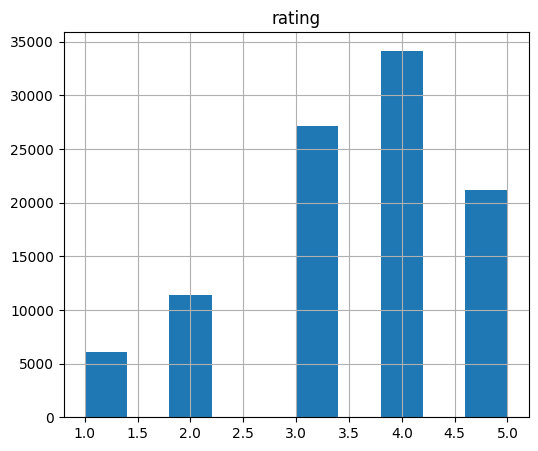

In [46]:
ratings.hist(column='rating', figsize=(6, 5))

A box-and-whisker plot gives another view of the same distribution, showing the median, quartiles, and any outliers.

<Axes: >

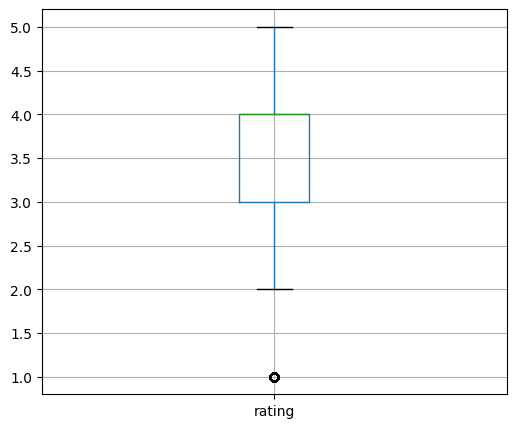

In [47]:
ratings.boxplot(column='rating', figsize=(6, 5))

### Number of Movies per Genre

Each genre in `movies` is stored as its own column, with `1` meaning the movie belongs to that genre and `0` meaning it doesn't.

To count how many movies fall under each genre, we sum each genre column.

In [50]:
genre_list = ['Action', 'Adventure', 'Animation', 'Childrens', 'Comedy', 'Crime',
              'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
              'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

genre_counts = movies[genre_list].sum()
genre_counts

Action         250
Adventure      135
Animation       42
Childrens      122
Comedy         505
Crime          109
Documentary     50
Drama          724
Fantasy         22
Film-Noir       24
Horror          92
Musical         56
Mystery         61
Romance        247
Sci-Fi         101
Thriller       251
War             71
Western         27
dtype: int64

<Axes: title={'center': 'Number of Movies per Genre'}, xlabel='Genre', ylabel='Number of Movies'>

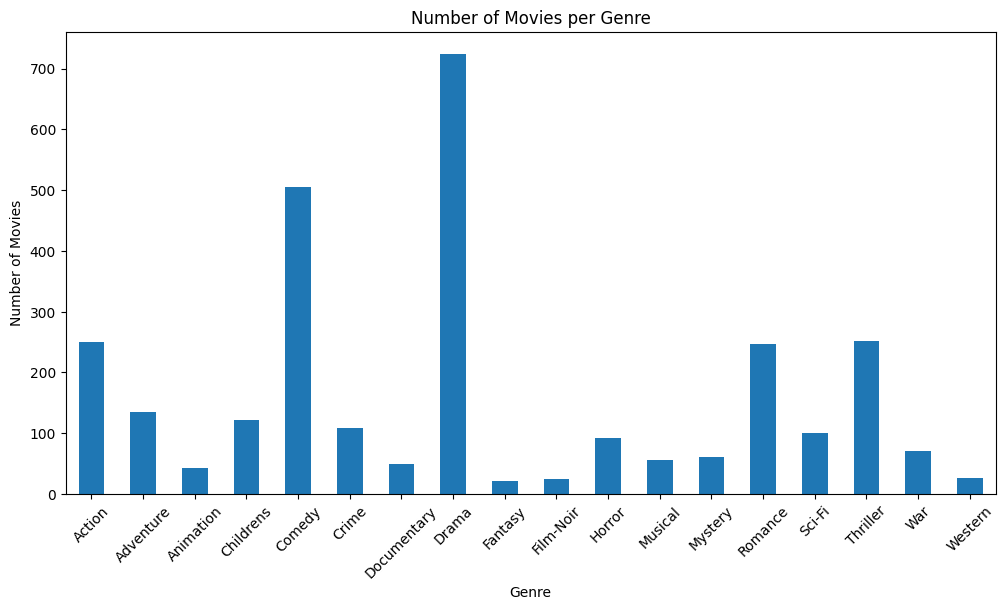

In [51]:
genre_counts.plot.bar(figsize=(12, 6), rot=45, xlabel='Genre', ylabel='Number of Movies',
                       title='Number of Movies per Genre')

### Class Exercise: Data Visualization (3 points)

- Draw a histogram of the `age` column in `users`
  
- Count how many users belong to each `occupation`, and plot it as a bar chart (**HINT:** use `.value_counts()`)

In [60]:
#YOUR_CODE_HERE

## Data Manipulation

Now let's practice combining and reshaping data, selecting specific columns/rows, grouping and aggregating, merging DataFrames together, and working with text and dates.

In this section, we will cover:

- Selecting specific columns and rows
  
- Filtering with string conditions
  
- Group by and aggregate
  
- Merging DataFrames
  
- Working with timestamps

### Selecting Columns and Rows

We already saw basic filtering with boolean masks earlier. Let's now practice selecting specific columns and rows directly, using our MovieLens DataFrames.

In [61]:
users.head()

,user_id,age,gender,occupation,zipcode
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [62]:
# Extract only the occupation column
users['occupation'].head()

0    technician
1         other
2        writer
3    technician
4         other
Name: occupation, dtype: object

In [63]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [64]:
# Select rows from index 5 to 14 in ratings
ratings[5:15]

,user_id,movie_id,rating,timestamp
5,298,474,4,884182806
6,115,265,2,881171488
7,253,465,5,891628467
8,305,451,3,886324817
9,6,86,3,883603013
10,62,257,2,879372434
11,286,1014,5,879781125
12,200,222,5,876042340
13,210,40,3,891035994
14,224,29,3,888104457


### Filtering with String Conditions

We can also filter rows based on whether a text column contains a certain word, using `.str.contains()`.

In [ ]:
# Find movies with 'Star' in the title

is_star = movies['movie_title'].str.contains('Star')
movies[is_star].head()

,movie_id,movie_title,release_date,imdb_url,Action,Adventure,Animation,Childrens,Comedy,Crime,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
49,50,Star Wars (1977),01-Jan-1977,http://us.imdb.com/M/title-exact?Star%20Wars%2...,1,1,0,0,0,0,...,0,0,0,0,0,1,1,0,1,0
61,62,Stargate (1994),01-Jan-1994,http://us.imdb.com/M/title-exact?Stargate%20(1...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
123,124,Lone Star (1996),21-Jun-1996,http://us.imdb.com/M/title-exact?Lone%20Star%2...,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
145,146,Unhook the Stars (1996),30-Oct-1996,http://us.imdb.com/M/title-exact?Unhook%20the%...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
221,222,Star Trek: First Contact (1996),22-Nov-1996,http://us.imdb.com/M/title-exact?Star%20Trek:%...,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


### Group By and Aggregate

Grouping lets us split data into categories and then compute a summary statistic for each group, for example, the average rating given by each user, or the count of ratings per movie.

In [66]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [67]:
# Only keep movie_id and rating columns
ratings[['movie_id', 'rating']].head()

,movie_id,rating
0,242,3
1,302,3
2,377,1
3,51,2
4,346,1


In [68]:
# Count how many ratings each movie received
rating_counts = ratings[['movie_id', 'rating']].groupby('movie_id').count()
rating_counts.head()

,rating
movie_id,
1,452
2,131
3,90
4,209
5,86


In [69]:
# Average rating for each movie
average_rating = ratings[['movie_id', 'rating']].groupby('movie_id').mean()
average_rating.head()

,rating
movie_id,
1,3.878319
2,3.206107
3,3.033333
4,3.550239
5,3.302326


We can also group by a column in a different DataFrame, like finding the average age of users, grouped by occupation.

In [70]:
users[['occupation', 'age']].groupby('occupation').mean()

,age
occupation,
administrator,38.746835
artist,31.392857
doctor,43.571429
educator,42.010526
engineer,36.388060
entertainment,29.222222
executive,38.718750
healthcare,41.562500
homemaker,32.571429


### Merging DataFrames

So far, we've worked with `users`, `movies`, and `ratings` separately. But often questions require combining them, for example, "what's the average rating per genre?" needs both `movies` and `ratings` together.

`pd.merge()` combines two DataFrames based on a shared column, similar to a SQL join.

In [71]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [72]:
movies.head()

,movie_id,movie_title,release_date,imdb_url,Action,Adventure,Animation,Childrens,Comedy,Crime,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?GoldenEye%20(...,1,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Get%20Shorty%...,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0


In [73]:
# Merge ratings and movies on movie_id, using an inner join
ratings_movies = pd.merge(ratings, movies, on='movie_id', how='inner')
ratings_movies.head()

,user_id,movie_id,rating,timestamp,movie_title,release_date,imdb_url,Action,Adventure,Animation,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,196,242,3,881250949,Kolya (1996),24-Jan-1997,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,186,302,3,891717742,L.A. Confidential (1997),01-Jan-1997,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,0,0,...,0,1,0,0,1,0,0,1,0,0
2,22,377,1,878887116,Heavyweights (1994),01-Jan-1994,http://us.imdb.com/M/title-exact?Heavyweights%...,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,244,51,2,880606923,Legends of the Fall (1994),01-Jan-1994,http://us.imdb.com/M/title-exact?Legends%20of%...,0,0,0,...,0,0,0,0,0,1,0,0,1,1
4,166,346,1,886397596,Jackie Brown (1997),01-Jan-1997,http://us.imdb.com/M/title-exact?imdb-title-11...,0,0,0,...,0,0,0,0,0,0,0,0,0,0


An **inner join** keeps only the rows where the matching value (`movie_id`) exists in *both* DataFrames.

More on join types: https://pandas.pydata.org/docs/user_guide/merging.html

We can also merge `ratings` with `users` to bring in demographic info alongside each rating.

In [74]:
users.head()

,user_id,age,gender,occupation,zipcode
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [75]:
ratings_users = pd.merge(ratings, users, on='user_id', how='inner')
ratings_users.head()

,user_id,movie_id,rating,timestamp,age,gender,occupation,zipcode
0,196,242,3,881250949,49,M,writer,55105
1,186,302,3,891717742,39,F,executive,00000
2,22,377,1,878887116,25,M,writer,40206
3,244,51,2,880606923,28,M,technician,80525
4,166,346,1,886397596,47,M,educator,55113


And we can chain merges together, combining all three DataFrames into one.

In [76]:
full_df = pd.merge(ratings_movies, users, on='user_id', how='inner')
full_df.head()

,user_id,movie_id,rating,timestamp,movie_title,release_date,imdb_url,Action,Adventure,Animation,...,Mystery,Romance,Sci-Fi,Thriller,War,Western,age,gender,occupation,zipcode
0,196,242,3,881250949,Kolya (1996),24-Jan-1997,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,0,0,...,0,0,0,0,0,0,49,M,writer,55105
1,186,302,3,891717742,L.A. Confidential (1997),01-Jan-1997,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,0,0,...,1,0,0,1,0,0,39,F,executive,00000
2,22,377,1,878887116,Heavyweights (1994),01-Jan-1994,http://us.imdb.com/M/title-exact?Heavyweights%...,0,0,0,...,0,0,0,0,0,0,25,M,writer,40206
3,244,51,2,880606923,Legends of the Fall (1994),01-Jan-1994,http://us.imdb.com/M/title-exact?Legends%20of%...,0,0,0,...,0,1,0,0,1,1,28,M,technician,80525
4,166,346,1,886397596,Jackie Brown (1997),01-Jan-1997,http://us.imdb.com/M/title-exact?imdb-title-11...,0,0,0,...,0,0,0,0,0,0,47,M,educator,55113


### Working with Timestamps

The `timestamp` column in `ratings` records when each rating was made, but it's stored as raw seconds since midnight UTC, January 1, 1970. Let's convert it into an actual date so it's usable.

In [77]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [78]:
ratings.dtypes

user_id      int64
movie_id     int64
rating       int64
timestamp    int64
dtype: object

In [80]:
# Convert timestamp into a proper datetime column

ratings['rating_date'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings.head()

,user_id,movie_id,rating,timestamp,rating_date
0,196,242,3,881250949,1997-12-04 15:55:49
1,186,302,3,891717742,1998-04-04 19:22:22
2,22,377,1,878887116,1997-11-07 07:18:36
3,244,51,2,880606923,1997-11-27 05:02:03
4,166,346,1,886397596,1998-02-02 05:33:16


In [81]:
ratings.dtypes

user_id                 int64
movie_id                int64
rating                  int64
timestamp               int64
rating_date    datetime64[ns]
dtype: object

Now that `rating_date` is a real datetime column, we can filter by date ranges, sort by date, and extract parts of the date (year, month, etc.).

In [85]:
# Select ratings made after a certain date
recent_ratings = ratings[ratings['rating_date'] > '1998-01-01']
recent_ratings.head()

,user_id,movie_id,rating,timestamp,rating_date
1,186,302,3,891717742,1998-04-04 19:22:22
4,166,346,1,886397596,1998-02-02 05:33:16
5,298,474,4,884182806,1998-01-07 14:20:06
7,253,465,5,891628467,1998-04-03 18:34:27
8,305,451,3,886324817,1998-02-01 09:20:17


In [86]:
ratings.shape, recent_ratings.shape

((100000, 5), (47101, 5))

In [87]:
# Sort ratings by date, earliest first
ratings_sorted = ratings.sort_values(by='rating_date', ascending=True)
ratings_sorted.head()

,user_id,movie_id,rating,timestamp,rating_date
214,259,255,4,874724710,1997-09-20 03:05:10
83965,259,286,4,874724727,1997-09-20 03:05:27
43027,259,298,4,874724754,1997-09-20 03:05:54
21396,259,185,4,874724781,1997-09-20 03:06:21
82655,259,173,4,874724843,1997-09-20 03:07:23


In [88]:
# Extract just the year from rating_date
ratings['rating_year'] = ratings['rating_date'].dt.year
ratings.head()

,user_id,movie_id,rating,timestamp,rating_date,rating_year
0,196,242,3,881250949,1997-12-04 15:55:49,1997
1,186,302,3,891717742,1998-04-04 19:22:22,1998
2,22,377,1,878887116,1997-11-07 07:18:36,1997
3,244,51,2,880606923,1997-11-27 05:02:03,1997
4,166,346,1,886397596,1998-02-02 05:33:16,1998


### Class Exercise: Data Manipulation (5 points)

Using the `users`, `movies`, and `ratings` DataFrames, answer the following:

- Filter `movies` to show only movies with `'Trek'` in the title
  
- Merge `ratings` and `movies` on `movie_id` using an inner join
  
- Using the merged DataFrame, find the average rating for each `movie_title` (**HINT:** use `.groupby()`
  
- Convert the `timestamp` column in `ratings` to a proper datetime column
  
- Extract the year from the converted date, and find the average rating given per year

In [95]:
# Filter movies with 'Trek' in the title

# YOUR CODE HERE

In [96]:
# Merge ratings and movies on movie_id

# YOUR CODE HERE

In [97]:
# Average rating for each movie_title

# YOUR CODE HERE

In [98]:
# Convert timestamp to datetime

# YOUR CODE HERE

In [99]:
# Extract year and find average rating per year

# YOUR CODE HERE

## Putting It All Together (5 points)

Let's finish with a combined analysis question that uses everything we've covered, merging, grouping, filtering, and correlation.

### Capstone Exercise

Using the `users`, `movies`, and `ratings` DataFrames, answer the following:

**Question:** Are older users more generous with their ratings than younger users? Is there a relationship between a user's age and the rating they give?

- Merge `ratings` and `users` on `user_id`
  
- Find the correlation between `age` and `rating` (**HINT:** use `.corr()`)
  
- Group the merged data by `age`, and find the average rating per age
  
- Plot the average rating per age as a line chart

In [1]:
# Merge ratings and users on user_id

# YOUR CODE HERE

In [2]:
# Correlation between age and rating

# YOUR CODE HERE

In [3]:
# Average rating per age

# YOUR CODE HERE

In [4]:
# Plot average rating per age

# YOUR CODE HERE